# Plot Figure 3D: Normalized concentration profiles

Plots fitted concentration profiles of HQNO and RHL normalized to regression coefficient of survival model.

This code is provided here for completeness only, full code containing model fitting and parameter inference is provided in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel) 

In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json

def uptake_diffusion_sinh(x, c0, L, A):
    """
    Calculates numerically stable uptake–diffusion concentration profile, assuming zero boundary condition at x=L.

    Parameters:
    - x: array-like, positions along the gradient
    - c0: float, maximum concentration at x=0
    - L: float, length of the domain
    - A: float, uptake/diffusion rate [1/m^2]

    Returns:
    - c: array-like, concentration at positions x
    c(x) = c0 * sinh(sqrt(A)*(L - x)) / sinh(sqrt(A)*L)

    """
    sA = np.sqrt(A)
    return c0 * np.sinh(sA * (L - x)) / np.sinh(sA * L)

def create_concentration_profile(df, x_vals):
    """
    Generate concentration profiles for all replicates at specified x positions.
    
    Parameters:
    - df: DataFrame containing fit parameters (c0, L, A) and unique_id
    - x_vals: array-like, positions along the gradient where concentrations are calculated
    
    Returns:
    - conc_profiles: DataFrame with columns 'unique_id', 'x', and 'concentration'
    """
    conc_profiles_list = []
    for _, row in df.iterrows():
        unique_id = row['unique_id']
        c0 = row['c0']
        L = row['L']
        A = row['A']
        c_x = uptake_diffusion_sinh(x_vals, c0, L, A)
        conc_profile = {
            'unique_id': unique_id,
            'y_um': x_vals,
            'concentration': c_x,
        }
        conc_profiles_list.append(conc_profile)

    conc_profiles = pd.DataFrame(conc_profiles_list).explode(['y_um', 'concentration']).reset_index(drop=True)
    return conc_profiles

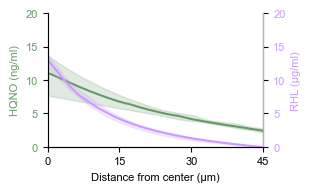

In [3]:
# ===========================================================
# Load parameters 
# ===========================================================

# Load model parameters
parameter_CSV = Path.cwd().parent / 'model_fit_parameters' / 'full_model_parameters.csv'
df = pd.read_csv(parameter_CSV)
df['unique_id'] = df['replicate'].astype(str) + '_' + df['pos'].astype(str)

# Load parameters of fitted survival models
survival_model = Path.cwd().parent / 'model_fit_parameters' / 'survival_model_parameters.json'
with open(survival_model, "r", encoding="utf-8") as f:
    logit_model = json.load(f)
# use parameters of the 'hqno_max_60' model as this fits the empirical concentration ranges best
model_params = logit_model['hqno_max_60']['parameters']


# get fitted rates
df_h = df[df['molecule'] == 'HQNO']
df_r = df[df['molecule'] == 'RHL']

# Generate high-resolution fitted curves for plotting
y_fit = np.linspace(0, 45, 181)
df_hqno = create_concentration_profile(df_h, y_fit)
df_rhl = create_concentration_profile(df_r, y_fit)

# Scale concentrations to match the empirical ranges observed in the survival data, using the fitted slopes of the logistic regression model
df_hqno['scaled_conc'] = model_params['m_hqno'] * df_hqno['concentration']
df_rhl['scaled_conc'] = np.abs(model_params['m_rhl']) * df_rhl['concentration']


final_width_in  = 8 / 2.54
final_height_in = 5 / 2.54
font_size = 8
plt.rcParams.update({
    'font.size': font_size,
    'font.family': 'Arial',
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

hqno_color = '#669966'
rhl_color  = '#cc99ff'

fig, ax1 = plt.subplots(figsize=(final_width_in, final_height_in))
ax2 = ax1.twinx()

# Plot HQNO (left axis) and RHL (right axis)
for ax, df_pred, color, ylabel, ylim, yticks in [
    (ax1, df_hqno, hqno_color, 'HQNO (ng/ml)', (0, 20), np.linspace(0, 20, 5)),
    (ax2, df_rhl, rhl_color,  'RHL (µg/ml)',  (0, 20), np.linspace(0, 20, 5)),
]:
    perc = df_pred.groupby('y_um')['scaled_conc'].agg([
        ('lower',  lambda x: np.percentile(x.dropna(), 25)),
        ('median', lambda x: np.percentile(x.dropna(), 50)),
        ('upper',  lambda x: np.percentile(x.dropna(), 75)),
    ]).reset_index().sort_values('y_um')
    ax.fill_between(perc['y_um'], perc['lower'], perc['upper'], alpha=0.2, color=color)
    ax.plot(perc['y_um'], perc['median'], '-', lw=1.5, color=color)
    ax.set_ylabel(ylabel, color=color, fontsize=font_size)
    ax.tick_params(axis='y', labelcolor=color, labelsize=font_size)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)

ax1.set_xlabel("Distance from center (µm)", fontsize=font_size)
ax1.set_xlim(0, 45)
ax1.set_xticks([0, 15, 30, 45])
ax1.tick_params(axis='x', labelsize=font_size)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_color(hqno_color)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color(rhl_color)

plt.tight_layout()
